In [1]:
import numpy as np
from pathlib import Path

UCI_DIR = Path("/lustre09/project/6081099/reem2005/DATASET/UCI HAR Dataset")

def load_signal(split, name):
    path = UCI_DIR / split / "Inertial Signals" / f"{name}_{split}.txt"
    return np.loadtxt(path)

SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def build_tensor(split):
    signals = [load_signal(split, name) for name in SIGNAL_NAMES]
    return np.stack(signals, axis=2)  # (samples, 128, 9)

X_train = build_tensor("train")
X_test = build_tensor("test")

y_train = np.loadtxt(UCI_DIR / "train" / "y_train.txt").astype(int) - 1
y_test = np.loadtxt(UCI_DIR / "test" / "y_test.txt").astype(int) - 1

subject_train = np.loadtxt(UCI_DIR / "train" / "subject_train.txt").astype(int)
subject_test = np.loadtxt(UCI_DIR / "test" / "subject_test.txt").astype(int)

# دمج train وtest مع بعض (متل ما عملنا بـ RealWorld، عشان نعمل LOSO بأنفسنا)
X = np.concatenate([X_train, X_test], axis=0).astype("float32")
y = np.concatenate([y_train, y_test], axis=0)
groups = np.concatenate([subject_train, subject_test], axis=0)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("عدد الأشخاص:", len(np.unique(groups)))
print("عدد الفئات:", len(np.unique(y)))

X shape: (10299, 128, 9)
y shape: (10299,)
groups shape: (10299,)
عدد الأشخاص: 30
عدد الفئات: 6


In [35]:
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [36]:
BATCH_SIZE = 128
EPOCHS = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 5.0

LABELED_FRACTION = 0.2
EMA_DECAY = 0.99
NOISE_STD = 0.05
CONSISTENCY_MAX_WEIGHT = 5.0
RAMPUP_EPOCHS = 10

INPUT_WINDOW = X.shape[1]      # 128
INPUT_FEATURES = X.shape[2]    # 9
NUM_CLASSES = len(np.unique(y))  # 6
RANDOM_SEED = 42

print(f"Window: {INPUT_WINDOW} | Features: {INPUT_FEATURES} | Classes: {NUM_CLASSES}")

Window: 100 | Features: 9 | Classes: 8


In [37]:
class SemiSupervisedHARDataset(Dataset):
    def __init__(self, X, y, is_labeled):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.is_labeled = torch.tensor(is_labeled, dtype=torch.bool)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.is_labeled[idx]

In [38]:
class CNN1DBase(nn.Module):
    def __init__(self, input_window, input_features, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, input_features, input_window)
            flat_dim = self.conv(dummy).flatten(1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        return self.classifier(x)

In [39]:
def update_ema(student, teacher, decay):
    with torch.no_grad():
        for t_param, s_param in zip(teacher.parameters(), student.parameters()):
            t_param.data.mul_(decay).add_(s_param.data, alpha=1 - decay)

def add_noise(x, std):
    return x + torch.randn_like(x) * std

def consistency_weight_rampup(epoch, rampup_epochs, max_weight):
    if epoch >= rampup_epochs:
        return max_weight
    phase = 1.0 - (epoch / rampup_epochs)
    return max_weight * float(np.exp(-5.0 * phase * phase))

In [40]:
def train_one_epoch_mt(student, teacher, loader, optimizer, class_weights,
                        consistency_weight, device):
    student.train()
    teacher.train()
    total_sup_loss, total_cons_loss = 0.0, 0.0

    for X_batch, y_batch, labeled_mask in loader:
        X_batch, y_batch, labeled_mask = X_batch.to(device), y_batch.to(device), labeled_mask.to(device)

        student_input = add_noise(X_batch, NOISE_STD)
        teacher_input = add_noise(X_batch, NOISE_STD)

        student_logits = student(student_input)
        with torch.no_grad():
            teacher_logits = teacher(teacher_input)

        if labeled_mask.any():
            sup_loss = F.cross_entropy(
                student_logits[labeled_mask], y_batch[labeled_mask], weight=class_weights,
            )
        else:
            sup_loss = torch.tensor(0.0, device=device)

        student_probs = F.softmax(student_logits, dim=1)
        teacher_probs = F.softmax(teacher_logits, dim=1)
        cons_loss = F.mse_loss(student_probs, teacher_probs)

        loss = sup_loss + consistency_weight * cons_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

        update_ema(student, teacher, EMA_DECAY)

        total_sup_loss += sup_loss.item() * X_batch.size(0)
        total_cons_loss += cons_loss.item() * X_batch.size(0)

    return total_sup_loss / len(loader.dataset), total_cons_loss / len(loader.dataset)

In [41]:
def evaluate_mt(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch, _ in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return f1_macro, all_labels, all_preds

In [42]:
def run_mean_teacher_loso(epochs=EPOCHS, labeled_fraction=LABELED_FRACTION, verbose=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    unique_subjects = np.unique(groups)

    results = {"baseline": {"fold_f1s": [], "y_true": [], "y_pred": []},
               "mean_teacher": {"fold_f1s": [], "y_true": [], "y_pred": []}}

    for fold, test_subject in enumerate(unique_subjects, 1):
        train_subjects = unique_subjects[unique_subjects != test_subject]
        train_mask = np.isin(groups, train_subjects)
        test_mask = groups == test_subject

        X_train_f, y_train_f = X[train_mask], y[train_mask]
        X_test_f, y_test_f = X[test_mask], y[test_mask]

        rng = np.random.RandomState(RANDOM_SEED + fold)
        n_train = len(y_train_f)
        n_labeled = int(n_train * labeled_fraction)
        labeled_idx = rng.choice(n_train, size=n_labeled, replace=False)
        is_labeled = np.zeros(n_train, dtype=bool)
        is_labeled[labeled_idx] = True

        class_counts = np.bincount(y_train_f[is_labeled], minlength=NUM_CLASSES)
        class_weights = torch.tensor(
            n_labeled / (NUM_CLASSES * np.maximum(class_counts, 1)), dtype=torch.float32
        ).to(device)

        full_loader = DataLoader(
            SemiSupervisedHARDataset(X_train_f, y_train_f, is_labeled),
            batch_size=BATCH_SIZE, shuffle=True
        )
        labeled_only_loader = DataLoader(
            SemiSupervisedHARDataset(X_train_f[is_labeled], y_train_f[is_labeled], np.ones(n_labeled, dtype=bool)),
            batch_size=BATCH_SIZE, shuffle=True
        )
        test_loader = DataLoader(
            SemiSupervisedHARDataset(X_test_f, y_test_f, np.ones(len(y_test_f), dtype=bool)),
            batch_size=BATCH_SIZE, shuffle=False
        )

        # Baseline: supervised فقط على الجزء المُصنّف
        baseline_model = CNN1DBase(INPUT_WINDOW, INPUT_FEATURES, NUM_CLASSES).to(device)
        optimizer_b = torch.optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        for epoch in range(epochs):
            baseline_model.train()
            for X_batch, y_batch, _ in labeled_only_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer_b.zero_grad()
                loss = F.cross_entropy(baseline_model(X_batch), y_batch, weight=class_weights)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), GRAD_CLIP_NORM)
                optimizer_b.step()

        f1_base, yt_base, yp_base = evaluate_mt(baseline_model, test_loader, device)

        # Mean Teacher: labeled + unlabeled
        student = CNN1DBase(INPUT_WINDOW, INPUT_FEATURES, NUM_CLASSES).to(device)
        teacher = copy.deepcopy(student).to(device)
        for p in teacher.parameters():
            p.requires_grad = False

        optimizer_mt = torch.optim.Adam(student.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        for epoch in range(epochs):
            cw = consistency_weight_rampup(epoch, RAMPUP_EPOCHS, CONSISTENCY_MAX_WEIGHT)
            train_one_epoch_mt(student, teacher, full_loader, optimizer_mt, class_weights, cw, device)

        f1_mt, yt_mt, yp_mt = evaluate_mt(teacher, test_loader, device)

        results["baseline"]["fold_f1s"].append(f1_base)
        results["baseline"]["y_true"].extend(yt_base)
        results["baseline"]["y_pred"].extend(yp_base)

        results["mean_teacher"]["fold_f1s"].append(f1_mt)
        results["mean_teacher"]["y_true"].extend(yt_mt)
        results["mean_teacher"]["y_pred"].extend(yp_mt)

        if verbose:
            print(f"Fold {fold:2d} | subject={test_subject:3d} | "
                  f"Baseline F1={f1_base:.4f} | MeanTeacher F1={f1_mt:.4f} | "
                  f"Δ={f1_mt - f1_base:+.4f}")

    for key in results:
        results[key]["mean_f1"] = np.mean(results[key]["fold_f1s"])
        results[key]["std_f1"] = np.std(results[key]["fold_f1s"])

    return results

In [ ]:
t0 = time.time()
uci_results = run_mean_teacher_loso(epochs=EPOCHS, labeled_fraction=LABELED_FRACTION, verbose=True)
elapsed = time.time() - t0

print(f"\n{'='*60}")
print(f"UCI HAR — Mean Teacher vs Baseline (LOSO, 30 folds)")
print(f"{'='*60}")
print(f"Baseline     — Mean F1: {uci_results['baseline']['mean_f1']:.4f} ± {uci_results['baseline']['std_f1']:.4f}")
print(f"Mean Teacher — Mean F1: {uci_results['mean_teacher']['mean_f1']:.4f} ± {uci_results['mean_teacher']['std_f1']:.4f}")
print(f"Time: {elapsed/60:.1f} min")

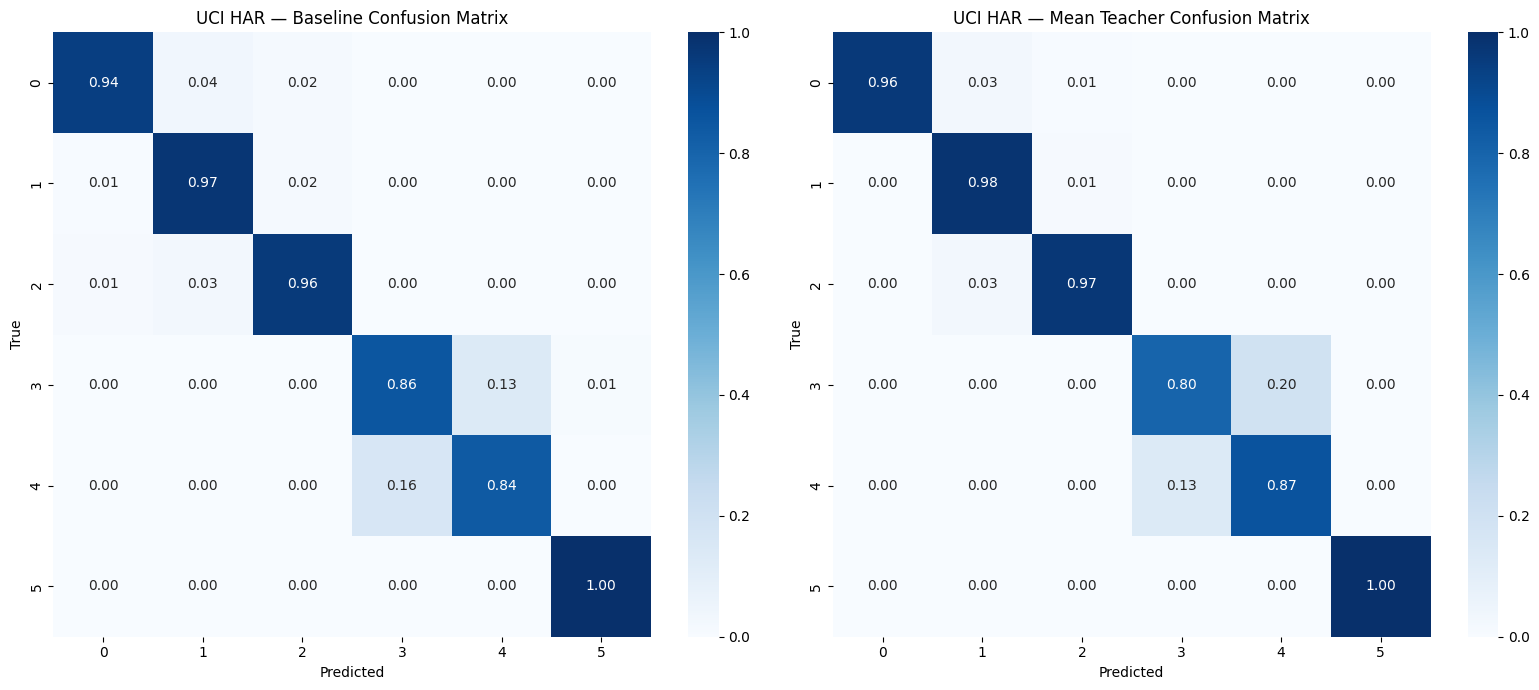

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(results, dataset_name):
    """Plots side-by-side confusion matrices for Baseline and Mean Teacher."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, (model_key, model_label) in zip(
        axes, [("baseline", "Baseline"), ("mean_teacher", "Mean Teacher")]
    ):
        y_true = results[model_key]["y_true"]
        y_pred = results[model_key]["y_pred"]
        cm = confusion_matrix(y_true, y_pred)
        cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=True)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"{dataset_name} — {model_label} Confusion Matrix")
    plt.tight_layout()
    plt.show()

# Usage
plot_confusion_matrices(uci_results, "UCI HAR")

In [22]:
# Load PAMAP2 windowed data (already prepared and saved earlier)
import numpy as np

X = np.load('/lustre09/project/6081099/reem2005/DATASET/X_windows.npy')
y = np.load('/lustre09/project/6081099/reem2005/DATASET/y_windows.npy')
groups = np.load('/lustre09/project/6081099/reem2005/DATASET/groups.npy')

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Number of subjects:", len(np.unique(groups)))
print("Number of classes:", len(np.unique(y)))

X shape: (28727, 100, 18)
y shape: (28727,)
groups shape: (28727,)
Number of subjects: 8
Number of classes: 8


In [31]:
# Run the experiment on PAMAP2
t0 = time.time()
pamap2_results = run_mean_teacher_loso(epochs=EPOCHS, labeled_fraction=LABELED_FRACTION, verbose=True)
elapsed = time.time() - t0

print(f"\n{'='*60}")
print(f"PAMAP2 — Mean Teacher vs Baseline (LOSO, {len(np.unique(groups))} folds)")
print(f"{'='*60}")
print(f"Baseline     — Mean F1: {pamap2_results['baseline']['mean_f1']:.4f} ± {pamap2_results['baseline']['std_f1']:.4f}")
print(f"Mean Teacher — Mean F1: {pamap2_results['mean_teacher']['mean_f1']:.4f} ± {pamap2_results['mean_teacher']['std_f1']:.4f}")
print(f"Time: {elapsed/60:.1f} min")

Fold  1 | subject=101 | Baseline F1=0.7024 | MeanTeacher F1=0.7071 | Δ=+0.0047
Fold  2 | subject=102 | Baseline F1=0.7199 | MeanTeacher F1=0.7029 | Δ=-0.0170
Fold  3 | subject=103 | Baseline F1=0.8169 | MeanTeacher F1=0.8495 | Δ=+0.0326
Fold  4 | subject=104 | Baseline F1=0.8842 | MeanTeacher F1=0.8647 | Δ=-0.0194
Fold  5 | subject=105 | Baseline F1=0.7911 | MeanTeacher F1=0.7980 | Δ=+0.0069
Fold  6 | subject=106 | Baseline F1=0.7976 | MeanTeacher F1=0.7721 | Δ=-0.0255
Fold  7 | subject=107 | Baseline F1=0.7431 | MeanTeacher F1=0.8377 | Δ=+0.0946
Fold  8 | subject=108 | Baseline F1=0.5216 | MeanTeacher F1=0.4241 | Δ=-0.0976

PAMAP2 — Mean Teacher vs Baseline (LOSO, 8 folds)
Baseline     — Mean F1: 0.7471 ± 0.1011
Mean Teacher — Mean F1: 0.7445 ± 0.1340
Time: 3.0 min


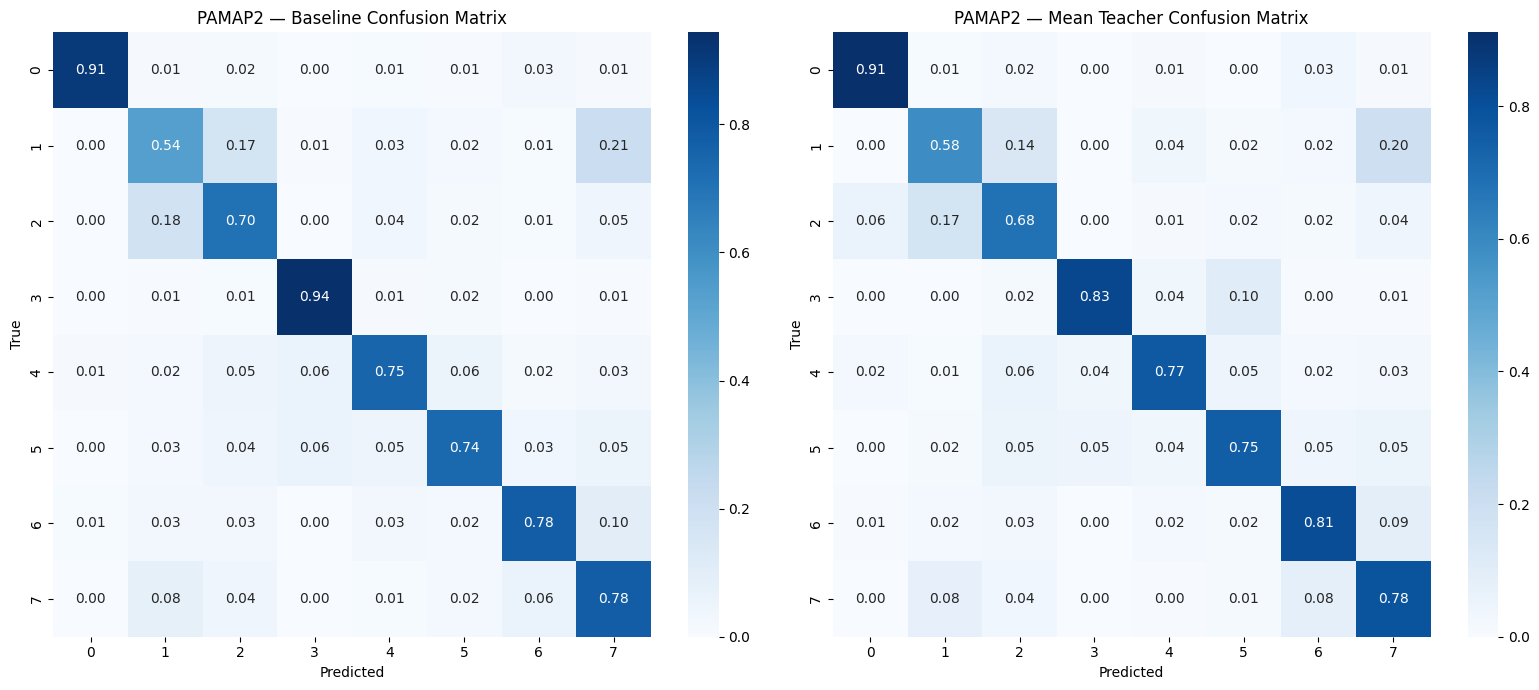

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(results, dataset_name):
    """Plots side-by-side confusion matrices for Baseline and Mean Teacher."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, (model_key, model_label) in zip(
        axes, [("baseline", "Baseline"), ("mean_teacher", "Mean Teacher")]
    ):
        y_true = results[model_key]["y_true"]
        y_pred = results[model_key]["y_pred"]
        cm = confusion_matrix(y_true, y_pred)
        cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=True)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"{dataset_name} — {model_label} Confusion Matrix")
    plt.tight_layout()
    plt.show()

# Usage
plot_confusion_matrices(pamap2_results, "PAMAP2")

In [33]:
import numpy as np

baseline_without_108 = [0.7024, 0.7199, 0.8169, 0.8842, 0.7911, 0.7976, 0.7431]
mt_without_108 = [0.7071, 0.7029, 0.8495, 0.8647, 0.7980, 0.7721, 0.8377]

print("Baseline (بدون subject 108):", np.mean(baseline_without_108))
print("Mean Teacher (بدون subject 108):", np.mean(mt_without_108))

Baseline (بدون subject 108): 0.7793142857142856
Mean Teacher (بدون subject 108): 0.7902857142857143


In [34]:
# Load RealWorld windowed data (already prepared and saved earlier)
import numpy as np
from pathlib import Path

DATA_DIR = Path("/lustre09/project/6081099/reem2005/DATASET/PROCESSED")

X = np.load(DATA_DIR / "X_windows.npy")
y = np.load(DATA_DIR / "y_windows.npy")
groups = np.load(DATA_DIR / "groups.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Number of subjects:", len(np.unique(groups)))
print("Number of classes:", len(np.unique(y)))

X shape: (435295, 100, 9)
y shape: (435295,)
groups shape: (435295,)
Number of subjects: 15
Number of classes: 8


In [43]:
# Run the experiment on RealWorld
t0 = time.time()
realworld_results = run_mean_teacher_loso(epochs=EPOCHS, labeled_fraction=LABELED_FRACTION, verbose=True)
elapsed = time.time() - t0

print(f"\n{'='*60}")
print(f"RealWorld — Mean Teacher vs Baseline (LOSO, {len(np.unique(groups))} folds)")
print(f"{'='*60}")
print(f"Baseline     — Mean F1: {realworld_results['baseline']['mean_f1']:.4f} ± {realworld_results['baseline']['std_f1']:.4f}")
print(f"Mean Teacher — Mean F1: {realworld_results['mean_teacher']['mean_f1']:.4f} ± {realworld_results['mean_teacher']['std_f1']:.4f}")
print(f"Time: {elapsed/60:.1f} min")

Fold  1 | subject=  0 | Baseline F1=0.6838 | MeanTeacher F1=0.7013 | Δ=+0.0174
Fold  2 | subject=  1 | Baseline F1=0.7582 | MeanTeacher F1=0.7973 | Δ=+0.0392
Fold  3 | subject=  2 | Baseline F1=0.7824 | MeanTeacher F1=0.7861 | Δ=+0.0037
Fold  4 | subject=  3 | Baseline F1=0.6852 | MeanTeacher F1=0.6905 | Δ=+0.0054
Fold  5 | subject=  4 | Baseline F1=0.7490 | MeanTeacher F1=0.7366 | Δ=-0.0124
Fold  6 | subject=  5 | Baseline F1=0.7114 | MeanTeacher F1=0.7287 | Δ=+0.0174
Fold  7 | subject=  6 | Baseline F1=0.7349 | MeanTeacher F1=0.7128 | Δ=-0.0222
Fold  8 | subject=  7 | Baseline F1=0.6893 | MeanTeacher F1=0.7600 | Δ=+0.0707
Fold  9 | subject=  8 | Baseline F1=0.7035 | MeanTeacher F1=0.6537 | Δ=-0.0498
Fold 10 | subject=  9 | Baseline F1=0.6347 | MeanTeacher F1=0.6500 | Δ=+0.0153
Fold 11 | subject= 10 | Baseline F1=0.6701 | MeanTeacher F1=0.6325 | Δ=-0.0376
Fold 12 | subject= 11 | Baseline F1=0.7407 | MeanTeacher F1=0.7427 | Δ=+0.0020
Fold 13 | subject= 12 | Baseline F1=0.7166 | MeanTea

In [44]:
from sklearn.metrics import classification_report

def print_classification_reports(results, dataset_name):
    """Prints classification reports for both Baseline and Mean Teacher.
    `results` must be a dict with 'baseline' and 'mean_teacher' keys,
    each containing 'y_true' and 'y_pred'."""

    print("=" * 60)
    print(f"{dataset_name} — Baseline Classification Report")
    print("=" * 60)
    print(classification_report(
        results["baseline"]["y_true"],
        results["baseline"]["y_pred"],
        digits=4
    ))

    print("\n" + "=" * 60)
    print(f"{dataset_name} — Mean Teacher Classification Report")
    print("=" * 60)
    print(classification_report(
        results["mean_teacher"]["y_true"],
        results["mean_teacher"]["y_pred"],
        digits=4
    ))

# Usage: just change the variable and name each time
print_classification_reports(realworld_results, "REALWORLD")

REALWORLD — Baseline Classification Report
              precision    recall  f1-score   support

           0     0.7803    0.7724    0.7763     48295
           1     0.7870    0.7580    0.7722     59670
           2     0.7998    0.9300    0.8600      9259
           3     0.6057    0.6772    0.6395     62692
           4     0.9462    0.7968    0.8651     68882
           5     0.4474    0.3426    0.3880     62525
           6     0.4924    0.6689    0.5672     61542
           7     0.7890    0.7540    0.7711     62430

    accuracy                         0.6849    435295
   macro avg     0.7060    0.7125    0.7049    435295
weighted avg     0.6955    0.6849    0.6858    435295


REALWORLD — Mean Teacher Classification Report
              precision    recall  f1-score   support

           0     0.8015    0.7694    0.7851     48295
           1     0.8345    0.7367    0.7826     59670
           2     0.8421    0.9182    0.8785      9259
           3     0.5612    0.6429    0.59

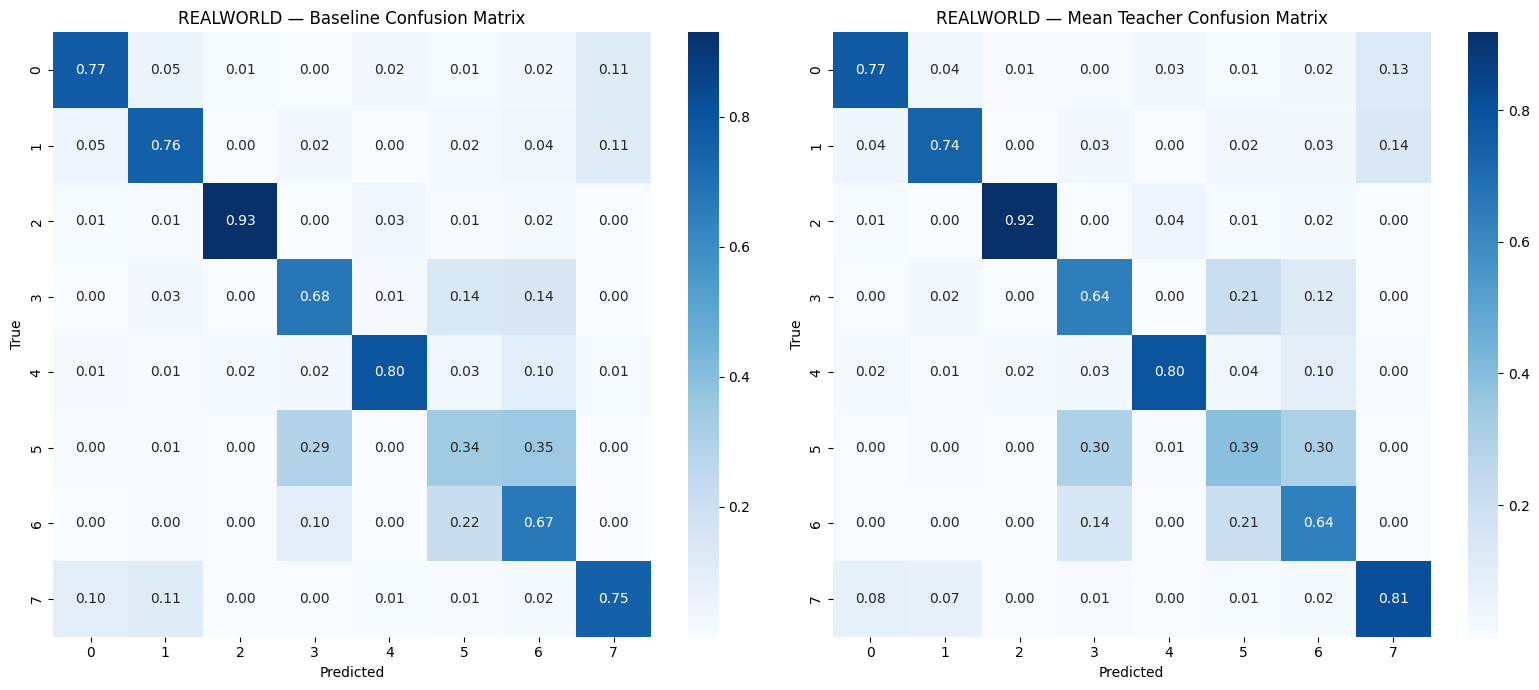

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(results, dataset_name):
    """Plots side-by-side confusion matrices for Baseline and Mean Teacher."""

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, (model_key, model_label) in zip(
        axes, [("baseline", "Baseline"), ("mean_teacher", "Mean Teacher")]
    ):
        y_true = results[model_key]["y_true"]
        y_pred = results[model_key]["y_pred"]

        cm = confusion_matrix(y_true, y_pred)
        cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=True)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"{dataset_name} — {model_label} Confusion Matrix")

    plt.tight_layout()
    plt.show()

# Usage: just change the variable and name each time
plot_confusion_matrices(realworld_results, "REALWORLD")